### Importing Libraries

In [1]:
import pickle
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score,
    mean_absolute_error, mean_squared_error,
)
from xgboost import XGBClassifier, XGBRegressor

warnings.filterwarnings("ignore")
np.random.seed(42)

### Loading Data and Graphs

In [2]:
# ── Raw data ──
df = pd.read_csv("final_delivery_data.csv")

# ── Graphs built in notebook 01 ──
with open("G_all.pkl",   "rb") as f: G_all   = pickle.load(f)
with open("G_rtype.pkl", "rb") as f: G_rtype = pickle.load(f)

print(f"Rows: {len(df):,}")
print(f"G_all   — {G_all.number_of_nodes():,} nodes | {G_all.number_of_edges():,} edges")
print(f"G_rtype — {G_rtype.number_of_nodes():,} nodes | {G_rtype.number_of_edges():,} edges")
print(f"Route types: {df['route_type'].unique().tolist()}")

Rows: 103,014
G_all   — 1,590 nodes | 2,508 edges
G_rtype — 1,590 nodes | 2,007,825 edges
Route types: ['Carting', 'FTL']


### Time of Day Bucket

In [3]:
# Match the exact bucketing used in notebook 01 when building G_rtype
df["od_start_time"] = pd.to_datetime(df["od_start_time"])

df["tod_bucket"] = pd.cut(
    df["od_start_time"].dt.hour,
    bins=[-1, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    include_lowest=True,
    right=False,
)

print(df["tod_bucket"].value_counts())

tod_bucket
Night        39356
Evening      26038
Morning      20639
Afternoon    16981
Name: count, dtype: int64


### Node-level Features from G_all

In [4]:
# ── Recompute betweenness + PageRank ──
# These were computed in notebook 02 for the graph model.
# We recompute here so Part 4 is self-contained.
# Runtime: ~30 seconds on this graph size.

print("Computing betweenness centrality...")
betweenness = nx.betweenness_centrality(G_all, weight="weight")

print("Computing PageRank...")
pagerank = nx.pagerank(G_all, weight="weight")

in_degree  = dict(G_all.in_degree())
out_degree = dict(G_all.out_degree())

# ── Build a node feature table ──
# For each facility we collect:
#   betweenness         — chokepoint importance (high = many paths flow through here)
#   pagerank            — flow authority
#   in/out degree       — connectivity
#   src_volume          — how many trips originate here (from G_all node attrs set in nb01)
#   avg_outgoing_factor — mean delay multiplier on outgoing corridors
#   pct_chronic_out     — share of outgoing corridors that are chronically delayed (>1.2x)
#   avg_out_pct_delayed — mean % of trips delayed leaving this node

node_records = []
for node in G_all.nodes():
    attrs     = G_all.nodes[node]
    out_edges = list(G_all.out_edges(node, data=True))
    in_edges  = list(G_all.in_edges(node, data=True))

    node_records.append({
        "center"            : node,
        "betweenness"       : betweenness.get(node, 0),
        "pagerank"          : pagerank.get(node, 0),
        "in_degree"         : in_degree.get(node, 0),
        "out_degree"        : out_degree.get(node, 0),
        # Node attrs written in notebook 01
        "src_volume"        : attrs.get("src_volume",          0),
        "dst_volume"        : attrs.get("dst_volume",          0),
        "total_volume"      : attrs.get("total_volume",        0),
        "avg_outgoing_factor": attrs.get("avg_outgoing_factor", np.nan),
        "pct_chronic_out"   : attrs.get("pct_chronic_outgoing", np.nan),
        # Derived from live edge data (handles NaN node attrs gracefully)
        "avg_out_pct_delayed": np.mean([d["pct_delayed"] for _,_,d in out_edges])
                               if out_edges else 0.0,
        "avg_in_pct_delayed" : np.mean([d["pct_delayed"] for _,_,d in in_edges])
                               if in_edges else 0.0,
    })

node_df = pd.DataFrame(node_records).set_index("center")
node_df = node_df.fillna(node_df.median())   # fill any NaN attrs with column median

print(f"Node feature table: {node_df.shape}")
node_df.head()

Computing betweenness centrality...
Computing PageRank...
Node feature table: (1590, 11)


,betweenness,pagerank,in_degree,out_degree,src_volume,dst_volume,total_volume,avg_outgoing_factor,pct_chronic_out,avg_out_pct_delayed,avg_in_pct_delayed
center,,,,,,,,,,,
IND590016AAA,0.000813,0.001194,2,1,6,42,48,1.596429,1.0,1.000000,1.000000
IND400072AAJ,0.000410,0.001615,2,1,2,64,66,9.000000,1.0,1.000000,0.982456
IND524201AAA,0.000808,0.000748,1,1,37,24,61,1.266667,1.0,0.648649,0.083333
IND686540AAA,0.000006,0.000310,2,1,2,14,16,1.920455,1.0,1.000000,1.000000
IND757025AAA,0.000000,0.000224,1,1,3,4,7,2.000000,1.0,1.000000,1.000000


### G_rtype Corridor-Level FTL vs Carting Delay Stats

In [5]:
# G_rtype edges store per-route-type per-time-of-day delay factors.
# We extract them into a flat DataFrame for easy joining onto trip rows.

rtype_records = []
for u, v, data in G_rtype.edges(data=True):
    rec = {"source_center": u, "destination_center": v}
    rec.update(data)
    rtype_records.append(rec)

rtype_edge_df = pd.DataFrame(rtype_records)

# The columns we care about most:
#   median_segment_factor_FTL_<tod>     — FTL delay ratio at that time of day
#   median_segment_factor_Carting_<tod> — Carting delay ratio at that time of day
#   pct_delayed_FTL_<tod>
#   pct_delayed_Carting_<tod>

print(f"G_rtype edge table: {rtype_edge_df.shape}")
factor_cols = [c for c in rtype_edge_df.columns if "median_segment_factor" in c]
print("Factor columns:", factor_cols)
rtype_edge_df[["source_center","destination_center"] + factor_cols].head()

G_rtype edge table: (2007825, 26)
Factor columns: ['median_segment_factor_Carting_Afternoon', 'median_segment_factor_Carting_Evening', 'median_segment_factor_Carting_Morning', 'median_segment_factor_Carting_Night', 'median_segment_factor_FTL_Afternoon', 'median_segment_factor_FTL_Evening', 'median_segment_factor_FTL_Morning', 'median_segment_factor_FTL_Night']


,source_center,destination_center,median_segment_factor_Carting_Afternoon,median_segment_factor_Carting_Evening,median_segment_factor_Carting_Morning,median_segment_factor_Carting_Night,median_segment_factor_FTL_Afternoon,median_segment_factor_FTL_Evening,median_segment_factor_FTL_Morning,median_segment_factor_FTL_Night
0,IND590016AAA,IND000000AAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,IND590016AAA,IND000000AAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,IND590016AAA,IND000000AAZ,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,IND590016AAA,IND000000ABA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,IND590016AAA,IND000000ABD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Build the Modelling Dataset

In [6]:
# Start from raw df so we have all columns before any encoding
feat_df = df[[
    "segment_actual_time",
    "segment_osrm_time",
    "segment_osrm_distance",
    "route_type",
    "hour_of_day",
    "day_of_week",
    "tod_bucket",
    "source_center",
    "destination_center",
    "is_delayed",
    "segment_factor",
    "time_gap",
    "actual_distance_to_destination",
]].copy()

feat_df = feat_df.dropna(subset=["segment_actual_time", "segment_osrm_time",
                                  "segment_osrm_distance", "route_type"])

# ── Join G_rtype corridor attributes ──
# This gives each trip row access to historical FTL and Carting delay factors
# for its specific corridor × time-of-day bucket.
feat_df = feat_df.merge(
    rtype_edge_df,
    on=["source_center", "destination_center"],
    how="left",
)

# ── Join source-node graph features ──
src_node = node_df.add_prefix("src_").reset_index().rename(columns={"center": "source_center"})
dst_node = node_df.add_prefix("dst_").reset_index().rename(columns={"center": "destination_center"})

feat_df = feat_df.merge(src_node, on="source_center", how="left")
feat_df = feat_df.merge(dst_node, on="destination_center", how="left")

# ── Historical FTL ratio per corridor (how often FTL is used here) ──
corridor_ftl_ratio = (
    df.groupby(["source_center", "destination_center"])
    .apply(lambda x: (x["route_type"] == "FTL").mean())
    .rename("corridor_ftl_ratio")
    .reset_index()
)
feat_df = feat_df.merge(corridor_ftl_ratio, on=["source_center","destination_center"], how="left")

# ── Fill NaNs from corridors with no G_rtype data ──
graph_cols = [c for c in feat_df.columns if c.startswith("src_") or c.startswith("dst_")
              or "median_segment_factor_" in c or "pct_delayed_" in c or "trip_count_" in c]
feat_df[graph_cols] = feat_df[graph_cols].fillna(0)
feat_df["corridor_ftl_ratio"] = feat_df["corridor_ftl_ratio"].fillna(0.5)

print(f"Feature dataset: {feat_df.shape}")
print(f"Missing values: {feat_df.isnull().sum().sum()}")

Feature dataset: (103014, 60)
Missing values: 0


### Encode Categoricals and Define Feature Sets

In [7]:
enc_df = feat_df.copy()

# Label-encode route_type (target for classifier): Carting=0, FTL=1
le_rt  = LabelEncoder()
enc_df["route_type_enc"] = le_rt.fit_transform(enc_df["route_type"])
# Check encoding
print("route_type encoding:", dict(zip(le_rt.classes_, le_rt.transform(le_rt.classes_))))

# Label-encode tod_bucket for use as a numeric feature
le_tod = LabelEncoder()
enc_df["tod_bucket_enc"] = le_tod.fit_transform(enc_df["tod_bucket"].astype(str))

# Label-encode source/destination centers
le_src = LabelEncoder()
le_dst = LabelEncoder()
enc_df["source_enc"]      = le_src.fit_transform(enc_df["source_center"].astype(str))
enc_df["destination_enc"] = le_dst.fit_transform(enc_df["destination_center"].astype(str))

# ── Feature sets ──────────────────────────────────────────────────────────────
# base_features: same trip-level features available at dispatch time
base_features = [
    "segment_osrm_time",          # OSRM estimated travel time (minutes)
    "segment_osrm_distance",      # OSRM estimated distance (km)
    "actual_distance_to_destination",  # actual geographic distance
    "hour_of_day",                # dispatch hour
    "day_of_week",                # dispatch day
    "tod_bucket_enc",             # night/morning/afternoon/evening
    "source_enc",                 # source facility (encoded)
    "destination_enc",            # destination facility (encoded)
    "corridor_ftl_ratio",         # historical share of FTL on this corridor
]

# G_rtype corridor features: per-route-type historical delay by time of day
# These are the most important differentiating features for the classifier
rtype_features = [c for c in enc_df.columns
                  if "median_segment_factor_" in c or "pct_delayed_" in c
                  or "trip_count_" in c]

# Node graph features from G_all
node_graph_features = [c for c in enc_df.columns
       if c.startswith("src_") or c.startswith("dst_")]

# Combined feature set for graph-enhanced models
graph_features = base_features + rtype_features + node_graph_features

print(f"Base features      : {len(base_features)}")
print(f"G_rtype features   : {len(rtype_features)}")
print(f"Node graph features: {len(node_graph_features)}")
print(f"Total graph features: {len(graph_features)}")

route_type encoding: {'Carting': np.int64(0), 'FTL': np.int64(1)}
Base features      : 9
G_rtype features   : 24
Node graph features: 22
Total graph features: 55


### Route-Type Classifier

In [8]:
# Input:  trip context (distance, time of day, corridor, source hub position)
# Output: P(FTL) — probability this corridor + context calls for FTL

# This is not predicting which route type will be faster.
# It is learning the historical pattern of when operators chose FTL vs Carting.
# The dual regressors in the next step handle the "which is faster" question.

X_cls = enc_df[graph_features].fillna(0)
y_cls = enc_df["route_type_enc"]   # 0 = Carting, 1 = FTL

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

clf = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss",
)
clf.fit(X_cls_train, y_cls_train)

y_cls_pred = clf.predict(X_cls_test)
y_cls_prob = clf.predict_proba(X_cls_test)[:, 1]   # P(FTL)
auc        = roc_auc_score(y_cls_test, y_cls_prob)

print(f"AUC-ROC: {auc:.4f}\n")
print(classification_report(y_cls_test, y_cls_pred, target_names=["Carting","FTL"]))

AUC-ROC: 1.0000

              precision    recall  f1-score   support

     Carting       1.00      1.00      1.00      6116
         FTL       1.00      1.00      1.00     14487

    accuracy                           1.00     20603
   macro avg       1.00      1.00      1.00     20603
weighted avg       1.00      1.00      1.00     20603



### Classifier Diagnostics

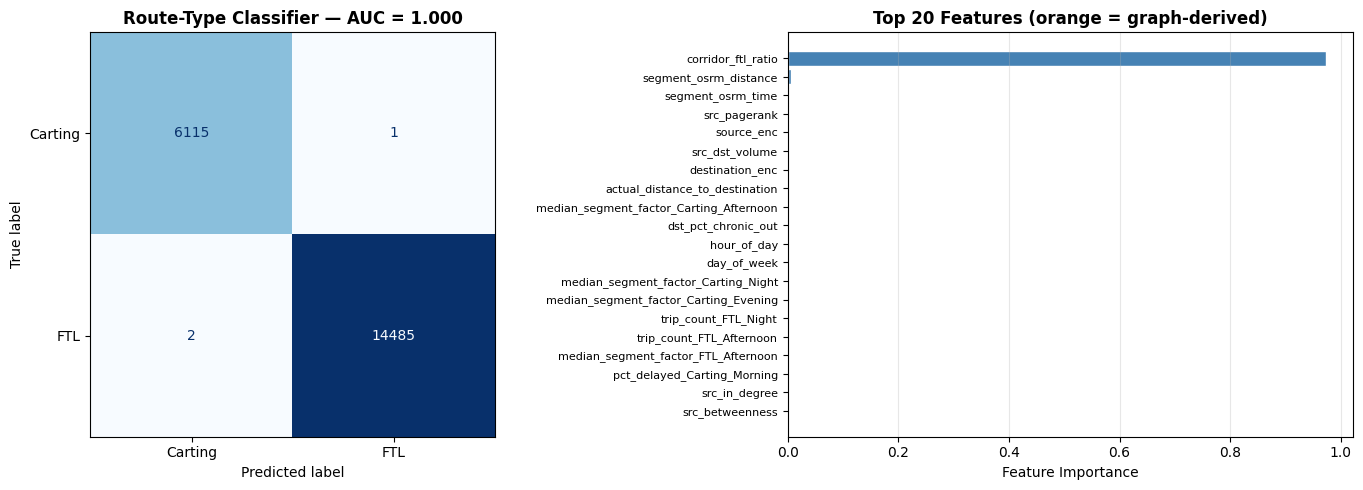

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confusion matrix
cm = confusion_matrix(y_cls_test, y_cls_pred)
ConfusionMatrixDisplay(cm, display_labels=["Carting","FTL"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title(f"Route-Type Classifier — AUC = {auc:.3f}", fontweight="bold")

# Right: top-20 feature importances, graph features highlighted in orange
fi = pd.Series(clf.feature_importances_, index=graph_features).sort_values(ascending=False).head(20)
colors = [
    "darkorange" if (c.startswith("src_") or c.startswith("dst_")
                     or "median_segment_factor_" in c or "pct_delayed_" in c)
    else "steelblue"
    for c in fi.index
]
axes[1].barh(range(len(fi)), fi.values, color=colors, edgecolor="white")
axes[1].set_yticks(range(len(fi)))
axes[1].set_yticklabels(fi.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Top 20 Features (orange = graph-derived)", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("classifier_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

### Dual Delay Regressors - One per Route Type

In [10]:
# ── Why dual regressors? ──
# A single model trained on all route types cannot estimate counterfactual times.
# ("If this FTL trip had gone as Carting, how long would it have taken?")
# By training separate models on FTL-only and Carting-only subsets, we can
# score ANY trip through BOTH models and compare the predicted times.
# The difference is the expected time saving from switching route type.

ftl_mask    = enc_df["route_type"] == "FTL"
carting_mask= enc_df["route_type"] == "Carting"

# We exclude route_type_enc from regressor features since the model is 
# already stratified — adding it would just be a perfect identifier
reg_features = [f for f in graph_features if f != "route_type_enc"]

def train_regressor(mask, label):
    sub = enc_df[mask]
    X   = sub[reg_features].fillna(0)
    y   = sub["segment_actual_time"]

    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

    model = XGBRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=6, random_state=42, n_jobs=-1,
    )
    model.fit(X_tr, y_tr)

    pred = model.predict(X_te)
    mae  = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    w15  = (np.abs(pred - y_te) / np.maximum(y_te, 1) <= 0.15).mean() * 100

    print(f"[{label:7s}]  n={len(sub):,}  MAE={mae:.2f} min  RMSE={rmse:.2f} min  Within-15%={w15:.1f}%")
    return model

print("Training FTL regressor...")
ftl_reg     = train_regressor(ftl_mask,     "FTL")

print("Training Carting regressor...")
carting_reg = train_regressor(carting_mask, "Carting")

Training FTL regressor...
[FTL    ]  n=72,433  MAE=13.55 min  RMSE=30.73 min  Within-15%=30.5%
Training Carting regressor...
[Carting]  n=30,581  MAE=9.48 min  RMSE=22.35 min  Within-15%=28.3%


### Decision Function

In [11]:
# ── Cost parameters ──
# These are the two levers an ops leader tunes from the rate card + SLA contract.
# Defaults are reasonable starting points; adjust to your actual numbers.

COST_PER_MIN_DELAY   = 2.0   # ₹ revenue-at-risk per minute of SLA breach
FTL_PREMIUM_PER_KM   = 8.0   # ₹ extra cost of FTL vs Carting per km

def recommend_route(
    osrm_time,               # OSRM estimated travel time (minutes)
    osrm_distance,           # OSRM estimated distance (km)
    actual_distance,         # actual distance to destination (km)
    hour_of_day,             # int 0–23
    day_of_week,             # int 0–6
    source_center,           # string facility code
    destination_center,      # string facility code
    cost_per_min  = COST_PER_MIN_DELAY,
    ftl_premium   = FTL_PREMIUM_PER_KM,
    verbose       = True,
):
    """
    Returns a dict with recommendation, expected times, and cost trade-off.
    """
    # ── Map tod_bucket ──
    h = hour_of_day
    tod_str = "Night" if h < 6 else "Morning" if h < 12 else "Afternoon" if h < 18 else "Evening"
    tod_enc = le_tod.transform([tod_str])[0] if tod_str in le_tod.classes_ else 0

    # ── Encode centers ──
    src_enc = (le_src.transform([source_center])[0]
               if source_center in le_src.classes_ else 0)
    dst_enc = (le_dst.transform([destination_center])[0]
               if destination_center in le_dst.classes_ else 0)

    # ── Node graph features ──
    src_g = (node_df.loc[source_center].values
             if source_center in node_df.index else np.zeros(len(node_df.columns)))
    dst_g = (node_df.loc[destination_center].values
             if destination_center in node_df.index else np.zeros(len(node_df.columns)))

    # ── G_rtype corridor features ──
    edge_match = rtype_edge_df[
        (rtype_edge_df["source_center"]      == source_center) &
        (rtype_edge_df["destination_center"] == destination_center)
    ]
    if len(edge_match) > 0:
        edge_vals = edge_match.iloc[0].drop(["source_center","destination_center"]).values
    else:
        edge_vals = np.zeros(len(rtype_features))

    # ── Historical FTL ratio ──
    corr_mask = (
        (corridor_ftl_ratio["source_center"]      == source_center) &
        (corridor_ftl_ratio["destination_center"] == destination_center)
    )
    ftl_ratio = float(corridor_ftl_ratio.loc[corr_mask, "corridor_ftl_ratio"].values[0]) \
                if corr_mask.any() else 0.5

    # ── Assemble feature vector (must match reg_features order) ──
    base_vec = [
        osrm_time, osrm_distance, actual_distance,
        hour_of_day, day_of_week, tod_enc,
        src_enc, dst_enc, ftl_ratio,
    ]
    full_vec = np.array(base_vec + list(edge_vals) + list(src_g) + list(dst_g),
                        dtype=float).reshape(1, -1)
    row_df = pd.DataFrame(full_vec, columns=reg_features)

    # ── Predictions ──
    p_ftl        = float(clf.predict_proba(
                     pd.DataFrame(full_vec, columns=graph_features))[0][1])
    pred_ftl     = float(ftl_reg.predict(row_df)[0])
    pred_carting = float(carting_reg.predict(row_df)[0])

    # ── Cost trade-off ──
    time_saved        = pred_carting - pred_ftl            # positive → FTL is faster
    delay_cost_saved  = cost_per_min * max(time_saved, 0)
    ftl_cost_premium  = ftl_premium  * (osrm_distance / 1000)  # distance in metres → km? check units
    # Note: segment_osrm_distance in the data is already in km (median ~23 km)
    # If yours is in metres, use: osrm_distance / 1000
    net_benefit_ftl   = delay_cost_saved - ftl_cost_premium

    # ── Recommendation ──
    if time_saved > 0 and net_benefit_ftl > 0:
        rec      = "FTL"
        rationale = (f"FTL saves {time_saved:.1f} min; delay cost recovered ₹{delay_cost_saved:.0f} "
                     f"exceeds FTL premium ₹{ftl_cost_premium:.0f}; net ₹{net_benefit_ftl:.0f}")
    elif time_saved > 0:
        rec      = "CARTING"
        rationale = (f"FTL is {time_saved:.1f} min faster but FTL premium ₹{ftl_cost_premium:.0f} "
                     f"> delay savings ₹{delay_cost_saved:.0f}")
    else:
        rec      = "CARTING"
        rationale = f"Carting is {-time_saved:.1f} min faster on this corridor"

    result = {
        "recommendation"       : rec,
        "p_ftl"                : round(p_ftl, 3),
        "pred_time_ftl_min"    : round(pred_ftl, 1),
        "pred_time_carting_min": round(pred_carting, 1),
        "time_saved_by_ftl_min": round(time_saved, 1),
        "ftl_cost_premium_inr" : round(ftl_cost_premium, 1),
        "delay_cost_saved_inr" : round(delay_cost_saved, 1),
        "net_benefit_ftl_inr"  : round(net_benefit_ftl, 1),
        "rationale"            : rationale,
    }

    if verbose:
        print(f"\n{'='*60}")
        print(f"  Corridor   : {source_center} → {destination_center}")
        print(f"  Time of day: {tod_str}  |  Day: {day_of_week}  |  Hour: {hour_of_day:02d}h")
        print(f"  OSRM time  : {osrm_time:.0f} min  |  Distance: {osrm_distance:.1f} km")
        print(f"  P(FTL) [classifier]: {p_ftl:.1%}")
        print(f"  Expected time — FTL: {pred_ftl:.1f} min  |  Carting: {pred_carting:.1f} min")
        print(f"  Time saved by FTL  : {time_saved:+.1f} min")
        print(f"  FTL cost premium   : ₹{ftl_cost_premium:.0f}")
        print(f"  Delay cost saved   : ₹{delay_cost_saved:.0f}")
        print(f"  Net benefit (FTL)  : ₹{net_benefit_ftl:.0f}")
        print(f"  ── RECOMMENDATION ── {rec}")
        print(f"  Rationale          : {rationale}")
        print(f"{'='*60}\n")

    return result

### Demo Call on a Real Corridor

In [12]:
# Pick a sample trip from the data to demo the function
sample = df.sample(1, random_state=99).iloc[0]

_ = recommend_route(
    osrm_time      = sample["segment_osrm_time"],
    osrm_distance  = sample["segment_osrm_distance"],
    actual_distance= sample["actual_distance_to_destination"],
    hour_of_day    = int(sample["hour_of_day"]),
    day_of_week    = int(sample["day_of_week"]),
    source_center  = sample["source_center"],
    destination_center = sample["destination_center"],
)


  Corridor   : IND263401AAA → IND263153AAB
  Time of day: Night  |  Day: 6  |  Hour: 05h
  OSRM time  : 14 min  |  Distance: 14.9 km
  P(FTL) [classifier]: 100.0%
  Expected time — FTL: 230.8 min  |  Carting: 229.3 min
  Time saved by FTL  : -1.5 min
  FTL cost premium   : ₹0
  Delay cost saved   : ₹0
  Net benefit (FTL)  : ₹-0
  ── RECOMMENDATION ── CARTING
  Rationale          : Carting is 1.5 min faster on this corridor



### Batch Corridor Audit

In [ ]:
# Score every unique corridor using its median/mode features
# This produces the intervention table for the ops memo

corridor_summary = df.groupby(["source_center","destination_center"]).agg(
    osrm_time       = ("segment_osrm_time",             "median"),
    osrm_distance   = ("segment_osrm_distance",          "median"),
    actual_distance = ("actual_distance_to_destination", "median"),
    hour_of_day     = ("hour_of_day",  lambda x: int(x.mode()[0])),
    day_of_week     = ("day_of_week",  lambda x: int(x.mode()[0])),
    trip_count      = ("segment_actual_time", "count"),
    pct_delayed     = ("is_delayed",          "mean"),
    median_factor   = ("segment_factor",      "median"),
    total_excess_min= ("time_gap",            "sum"),
).reset_index()

audit_rows = []
for _, row in corridor_summary.iterrows():
    try:
        r = recommend_route(
            osrm_time       = row["osrm_time"],
            osrm_distance   = row["osrm_distance"],
            actual_distance = row["actual_distance"],
            hour_of_day     = row["hour_of_day"],
            day_of_week     = row["day_of_week"],
            source_center   = row["source_center"],
            destination_center = row["destination_center"],
            verbose=False,
        )
        r.update({
            "source_center"     : row["source_center"],
            "destination_center": row["destination_center"],
            "trip_count"        : row["trip_count"],
            "pct_delayed"       : round(row["pct_delayed"], 3),
            "median_factor"     : round(row["median_factor"], 3),
            "total_excess_min"  : round(row["total_excess_min"], 1),
        })
        audit_rows.append(r)
    except Exception:
        pass

audit_df = pd.DataFrame(audit_rows)

print(f"Corridors audited   : {len(audit_df):,}")
print(f"Recommended FTL     : {(audit_df['recommendation']=='FTL').sum():,}")
print(f"Recommended CARTING : {(audit_df['recommendation']=='CARTING').sum():,}")
print()

# Top corridors where switching to FTL has highest net benefit
audit_df.nlargest(10, "net_benefit_ftl_inr")[[
    "source_center","destination_center",
    "recommendation","pred_time_ftl_min","pred_time_carting_min",
    "time_saved_by_ftl_min","net_benefit_ftl_inr",
    "trip_count","pct_delayed","median_factor"
]]

### Corridor Profile Classification

In [ ]:
# Classify every corridor into one of five actionable profiles
# These directly feed into the ops memo recommendations

q75_trips  = audit_df["trip_count"].quantile(0.75)
q75_excess = audit_df["total_excess_min"].quantile(0.75)

def classify_profile(row):
    chronic     = row["median_factor"] > 1.2
    high_volume = row["trip_count"]    > q75_trips
    high_excess = row["total_excess_min"] > q75_excess
    rec_ftl     = row["recommendation"] == "FTL"
    net_pos     = row["net_benefit_ftl_inr"] > 0

    if chronic and high_volume:
        return "CRITICAL — Upgrade or Parallel Route"
    elif chronic and rec_ftl and net_pos:
        return "SWITCH TO FTL"
    elif chronic:
        return "CHRONIC DELAY — Monitor"
    elif high_volume and rec_ftl and net_pos:
        return "HIGH VOLUME — FTL Opportunity"
    else:
        return "STABLE"

audit_df["profile"] = audit_df.apply(classify_profile, axis=1)

profile_summary = (
    audit_df.groupby("profile")
    .agg(
        corridor_count = ("source_center", "count"),
        total_trips    = ("trip_count",    "sum"),
        total_excess_min=("total_excess_min","sum"),
        avg_pct_delayed= ("pct_delayed",   "mean"),
    )
    .sort_values("total_excess_min", ascending=False)
    .reset_index()
)

print(profile_summary.to_string(index=False))

### Visualization

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ── Top-left: time saved vs OSRM distance, coloured by recommendation ──
ax = axes[0][0]
mask_ftl  = audit_df["recommendation"] == "FTL"
mask_cart = ~mask_ftl

ax.scatter(
    audit_df.loc[mask_cart, "osrm_distance"],
    audit_df.loc[mask_cart, "time_saved_by_ftl_min"],
    alpha=0.35, s=18, c="steelblue", label="Recommend Carting",
)
ax.scatter(
    audit_df.loc[mask_ftl, "osrm_distance"],
    audit_df.loc[mask_ftl, "time_saved_by_ftl_min"],
    alpha=0.45, s=25, c="darkorange", label="Recommend FTL",
)
ax.axhline(0, color="crimson", ls="--", lw=1.2, label="Break-even (time)")
ax.set_xlabel("OSRM Distance (km)")
ax.set_ylabel("Time Saved by FTL (min)\n← Carting faster  |  FTL faster →")
ax.set_title("FTL Time Advantage vs Corridor Distance", fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Top-right: net cost benefit distribution ──
ax = axes[0][1]
ax.hist(audit_df["net_benefit_ftl_inr"], bins=60, color="teal", edgecolor="white")
ax.axvline(0, color="crimson", ls="--", lw=1.5, label="Break-even (cost)")
ax.set_xlabel("Net Benefit of FTL vs Carting (₹ per corridor)")
ax.set_ylabel("Number of Corridors")
ax.set_title("Cost-Adjusted Net Benefit Distribution", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)

# ── Bottom-left: profile distribution bar chart ──
ax = axes[1][0]
profile_colors = {
    "CRITICAL — Upgrade or Parallel Route": "crimson",
    "SWITCH TO FTL":                        "darkorange",
    "CHRONIC DELAY — Monitor":              "gold",
    "HIGH VOLUME — FTL Opportunity":        "teal",
    "STABLE":                               "steelblue",
}
bars = ax.barh(
    profile_summary["profile"],
    profile_summary["corridor_count"],
    color=[profile_colors.get(p, "grey") for p in profile_summary["profile"]],
    edgecolor="white",
)
for bar, (_, row) in zip(bars, profile_summary.iterrows()):
    ax.text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
        f"{row['total_trips']:,.0f} trips",
        va="center", fontsize=8,
    )
ax.set_xlabel("Number of Corridors")
ax.set_title("Corridor Intervention Profiles", fontweight="bold")
ax.grid(axis="x", alpha=0.3)

# ── Bottom-right: top 20 corridors by net FTL benefit ──
ax = axes[1][1]
top20 = audit_df[audit_df["recommendation"]=="FTL"].nlargest(20, "net_benefit_ftl_inr")
labels = top20["source_center"].str[-6:] + " → " + top20["destination_center"].str[-6:]
ax.barh(range(len(top20)), top20["net_benefit_ftl_inr"], color="darkorange", edgecolor="white")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(labels, fontsize=7)
ax.invert_yaxis()
ax.set_xlabel("Net Benefit of Switching to FTL (₹)")
ax.set_title("Top 20 Corridors — Priority FTL Switch", fontweight="bold")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("ftl_carting_trade_off.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ftl_carting_trade_off.png")

### Sensitivty Analysis

In [ ]:
# Show how the FTL recommendation rate changes as the two cost levers are varied.
# This is what an ops leader needs to tune the framework to their rate card.

cost_per_min_range = np.arange(0.5, 6.0, 0.5)   # ₹0.5 to ₹5.5 per delayed minute
ftl_premium_range  = np.arange(2.0, 14.0, 2.0)   # ₹2 to ₹12 per km premium

# For speed, we use audit_df directly (re-apply cost formula without re-running models)
sensitivity_rows = []
for cpm in cost_per_min_range:
    for fpp in ftl_premium_range:
        ftl_rec = (
            (audit_df["delay_cost_saved_inr"] / np.where(audit_df["time_saved_by_ftl_min"] > 0,
                                                           COST_PER_MIN_DELAY, 1) * cpm
             - audit_df["ftl_cost_premium_inr"] / FTL_PREMIUM_PER_KM * fpp) > 0
        ) & (audit_df["time_saved_by_ftl_min"] > 0)
        
        sensitivity_rows.append({
            "cost_per_min"   : cpm,
            "ftl_premium_km" : fpp,
            "pct_corridors_ftl": ftl_rec.mean() * 100,
        })

sens_df = pd.DataFrame(sensitivity_rows)
pivot   = sens_df.pivot("cost_per_min", "ftl_premium_km", "pct_corridors_ftl")

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    pivot, annot=True, fmt=".0f", cmap="RdYlGn",
    cbar_kws={"label": "% Corridors Recommended FTL"},
    ax=ax
)
ax.set_xlabel("FTL Cost Premium (₹/km)", fontsize=11)
ax.set_ylabel("Delay Cost Rate (₹/min)", fontsize=11)
ax.set_title("Sensitivity: % Corridors Recommended FTL\nby Cost Assumption",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("sensitivity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sensitivity_heatmap.png")

### Final Output Table

In [ ]:
# Clean table of the top corridors by intervention priority
ops_table = (
    audit_df[audit_df["profile"] != "STABLE"]
    .sort_values(["profile","total_excess_min"], ascending=[True, False])
    [[
        "profile","source_center","destination_center",
        "recommendation","pred_time_ftl_min","pred_time_carting_min",
        "time_saved_by_ftl_min","net_benefit_ftl_inr",
        "trip_count","pct_delayed","median_factor","total_excess_min"
    ]]
    .rename(columns={
        "pred_time_ftl_min"     : "ETA_FTL",
        "pred_time_carting_min" : "ETA_Carting",
        "time_saved_by_ftl_min" : "Time_Saved",
        "net_benefit_ftl_inr"   : "Net_Benefit_INR",
        "total_excess_min"      : "Total_Excess_Min",
    })
)

print(f"Corridors requiring intervention: {len(ops_table):,}")
ops_table.to_csv("corridor_intervention_table.csv", index=False)
print("Saved: corridor_intervention_table.csv")
ops_table.head(20)